In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 


In [3]:
df = pd.read_csv("results2.csv")
parts = df["Name"].str.split("/", expand=True)
df["Algo"] = parts[0]
df["Size"] = pd.to_numeric(parts[1], errors="coerce")
df.head()

,Name,Mean,MeanLB,MeanUB,Stddev,StddevLB,StddevUB,Algo,Size
0,STree search/1,7.074229e-08,6.995006e-08,7.150107e-08,2.614056e-09,2.308966e-09,3.016034e-09,STree search,1
1,STree search/2,1.801659e-07,1.777411e-07,1.833095e-07,9.694388e-09,8.250406e-09,1.199025e-08,STree search,2
2,STree search/4,5.344228e-07,5.270790e-07,5.406062e-07,2.241484e-08,1.905531e-08,2.604050e-08,STree search,4
3,STree search/8,1.519445e-06,1.500637e-06,1.541233e-06,7.033091e-08,6.054707e-08,9.214330e-08,STree search,8
4,STree search/16,3.761998e-06,3.710503e-06,3.813153e-06,1.691924e-07,1.470530e-07,1.921699e-07,STree search,16


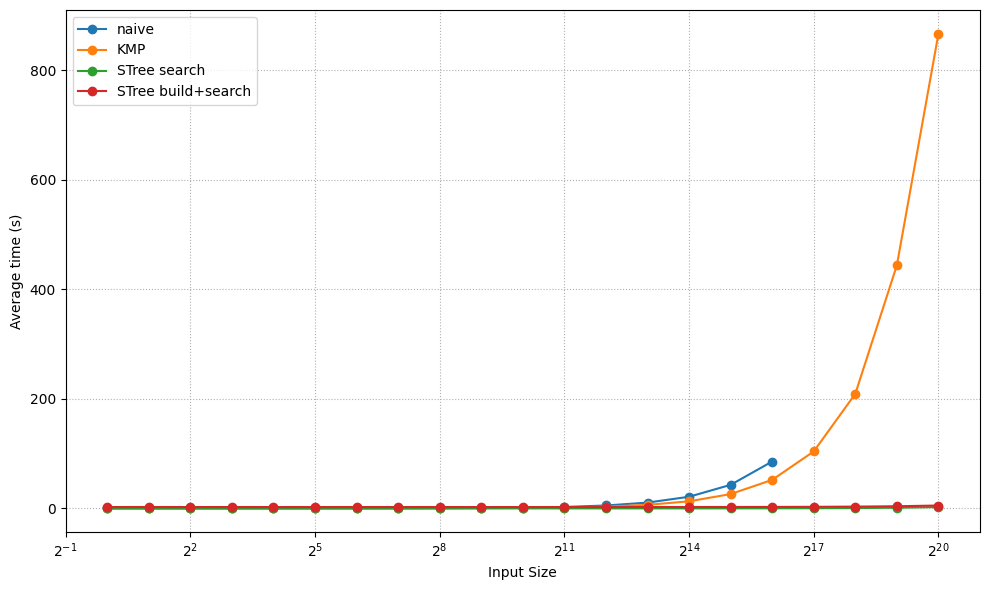

In [4]:
# df_naive = df[df["Algo"] == "naive"].sort_values("Size")
# df_kmp = df[df["Algo"] == "KMP"].sort_values("Size")
# df_stree = df[df["Algo"] == "STree search"].sort_values("Size")
# df_stree_build = df[df["Algo"] == "STree build+search"].sort_values("Size")

algos = ["naive", "KMP", "STree search", "STree build+search"]

plt.figure(figsize=(10, 6))
#plt.title("Plot comparing the best case scenario for insertion when elements are inserted into BST and RBT random order")
plt.xlabel("Input Size")
plt.ylabel("Average time (s)")
plt.xscale("log", base=2)
# plt.yscale("log", base=2)

for algo in algos:
    df_algo = df[df["Algo"] == algo].sort_values("Size")
    x, y = df_algo["Size"].to_numpy(), df_algo["Mean"].to_numpy()
    plt.plot(x, y, marker="o", label=algo)

plt.grid(True, which="both", linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

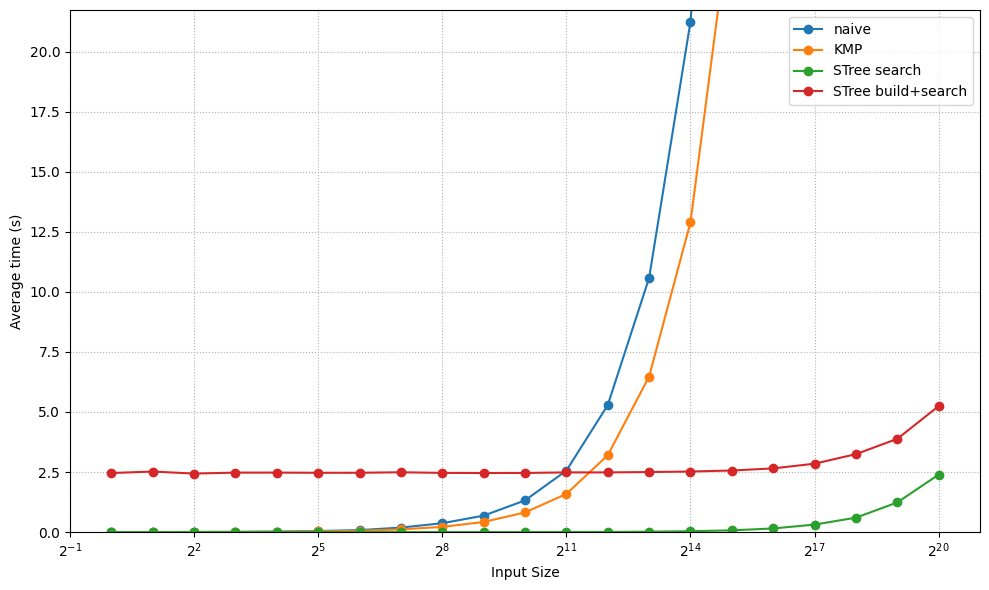

In [6]:
import numpy as np

algos = ["naive", "KMP", "STree search", "STree build+search"]

all_y = df["Mean"].to_numpy()
upper = np.percentile(all_y, 90)

plt.figure(figsize=(10, 6))
plt.xlabel("Input Size")
plt.ylabel("Average time (s)")
plt.xscale("log", base=2)
plt.ylim(0, upper)

for algo in algos:
    df_algo = df[df["Algo"] == algo].sort_values("Size")
    x, y = df_algo["Size"].to_numpy(), df_algo["Mean"].to_numpy()
    plt.plot(x, y, marker="o", label=algo)

plt.grid(True, which="both", linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()